In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [15]:
df = pd.read_csv("EarthquakeData.csv")
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

In [17]:
df['target'] = (df['Magnitude'] >= 6.0).astype(int)
features = ['Latitude', 'Longitude', 'Depth']
X = df[features]
y = df['target']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
model = KNeighborsClassifier(n_neighbors=8)
model.fit(X_train_scaled, y_train)

,n_neighbors,8
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
y_pred = model.predict(X_test_scaled)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy:  0.66944266495836
Precision:  0.4329501915708812
Recall:  0.15290933694181327
F1 Score:  0.226

Confusion Matrix:
 [[2909  296]
 [1252  226]]


In [22]:
lat = float(input("Enter Latitude (-90 to 90): "))
lon = float(input("Enter Longitude (-180 to 180): "))
depth = float(input("Enter Depth (in km): "))
user_data = scaler.transform([[lat, lon, depth]])
pred = model.predict(user_data)

print("\nPredicted Class:", pred[0])
if pred[0] == 1:
    print("Warning: High Magnitude / Severe Earthquake Risk (>= 6.0)")
else:
    print("Status: Moderate Earthquake (Magnitude < 6.0)")

Enter Latitude (-90 to 90):  75
Enter Longitude (-180 to 180):  23
Enter Depth (in km):  987



Predicted Class: 1


C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


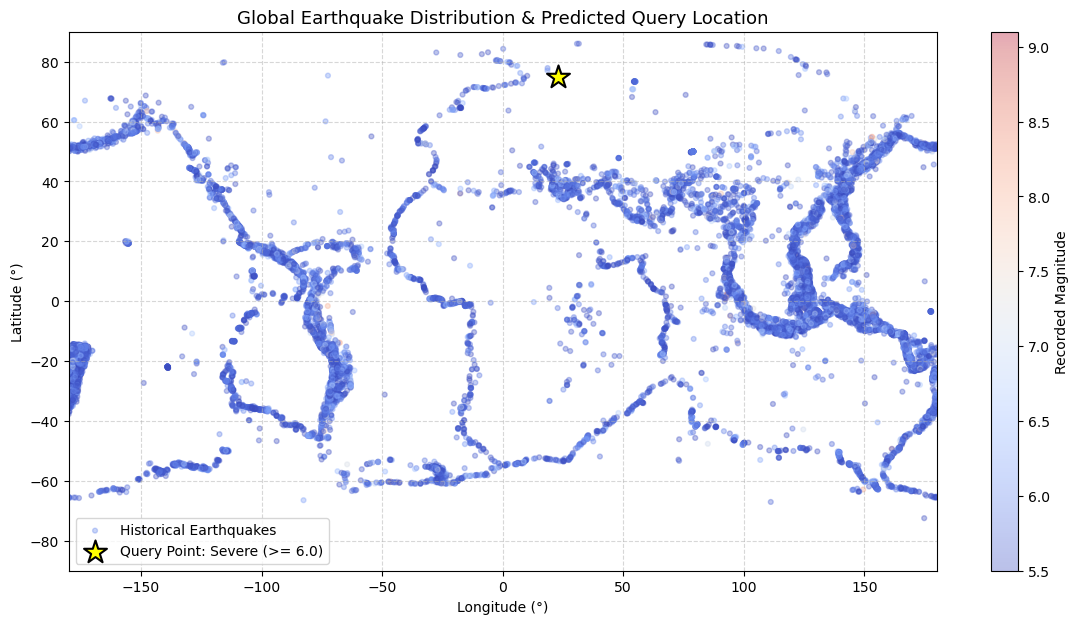

In [23]:
plt.figure(figsize=(14, 7))
scatter = plt.scatter(
    df['Longitude'], 
    df['Latitude'], 
    c=df['Magnitude'], 
    cmap='coolwarm', 
    alpha=0.35, 
    s=12,
    label='Historical Earthquakes'
)
plt.colorbar(scatter, label='Recorded Magnitude')
pred_label = f"Query Point: {'Severe (>= 6.0)' if pred[0] == 1 else 'Moderate (< 6.0)'}"
plt.scatter(lon, lat, color='yellow', marker='*', s=300, edgecolor='black', linewidth=1.5, label=pred_label)

plt.title("Global Earthquake Distribution & Predicted Query Location", fontsize=13)
plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left')

plt.show()